<a href="https://colab.research.google.com/github/LaraDondossola/Data-science/blob/main/desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


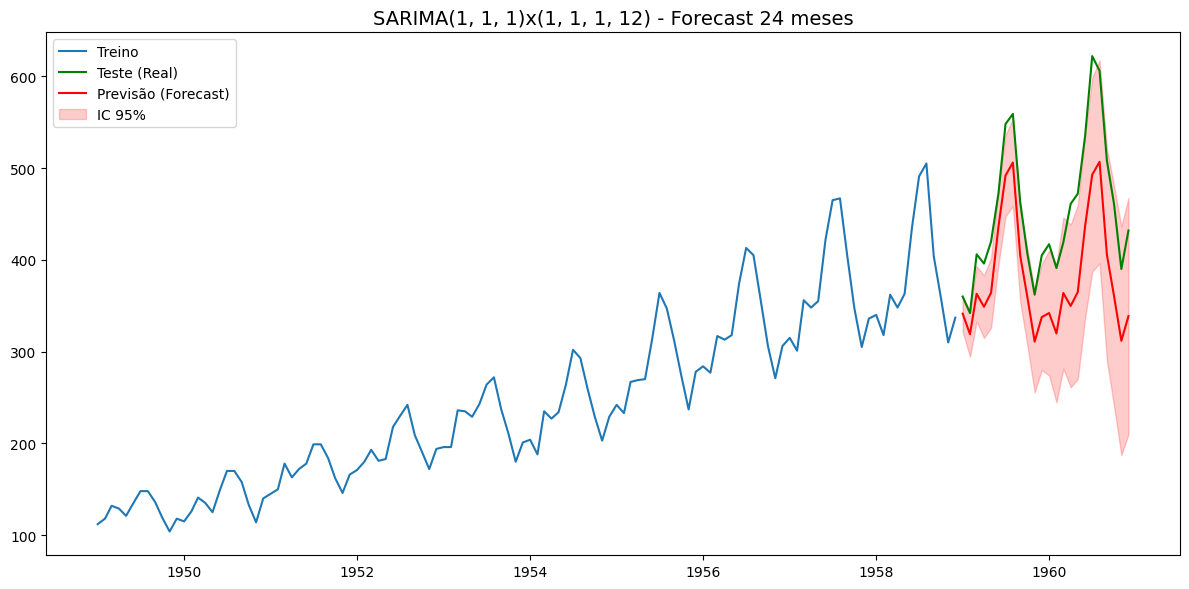

MAE: (erro médio absoluto) 69.896
RMSE: (penaliza erros maiores) 75.625
MAPE: (erro percentual médio) 15.22%


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1) Leitura dos dados
df = pd.read_csv('AirPassengers-6a03b7a88a54a.csv', parse_dates=['Month'], index_col='Month')
y = df['#Passengers']

# 2) Definição do horizonte de previsão e separação Treino/Teste
h = 24  # Exemplo de previsão para 24 meses
y_train = y.iloc[:-h]
y_test = y.iloc[-h:]

# 3) Ajuste do modelo SARIMA (substitua pelas ordens que você definiu no notebook)
best_order = (1, 1, 1)
best_seasonal = (1, 1, 1, 12)

model = SARIMAX(y_train,
                order=best_order,
                seasonal_order=best_seasonal,
                enforce_invertibility=False,
                enforce_stationarity=False)
results = model.fit(disp=False)

# 4) Previsão (Forecast) e Intervalos de Confiança
forecast_obj = results.get_forecast(steps=h)
fc_mean = forecast_obj.predicted_mean
fc_ci = forecast_obj.conf_int(alpha=0.05) # IC de 95%

# 5) O Gráfico Final (Conforme o final do seu arquivo ipynb)
plt.figure(figsize=(12, 6))

# Plotando Treino e Teste
plt.plot(y_train.index, y_train, label="Treino")
plt.plot(y_test.index, y_test, label="Teste (Real)", color='green')

# Plotando a Previsão e o Intervalo de Confiança (IC)
plt.plot(fc_mean.index, fc_mean, color='red', label="Previsão (Forecast)")
plt.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], color='red', alpha=0.2, label="IC 95%")

plt.title(f"SARIMA{best_order}x{best_seasonal} - Forecast {h} meses", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# 6) Métricas finais do seu código
mae = mean_absolute_error(y_test, fc_mean)
rmse = np.sqrt(mean_squared_error(y_test, fc_mean))
mape = mean_absolute_percentage_error(y_test, fc_mean)

print(f"MAE: (erro médio absoluto) {mae:.3f}")
print(f"RMSE: (penaliza erros maiores) {rmse:.3f}")
print(f"MAPE: (erro percentual médio) {mape:.2%}")